# Sleep Disorder Risk Classification 

**Author:** Gavrila Robert Daniel  
**Dataset:** Sleep Health and Daily Performance Dataset (Kaggle, 100 000 records, 32 features)  
**Task:** Predict **sleep disorder risk** level: Healthy / Mild / Moderate / Severe

---
1. [Dataset Description](#1-dataset-description)
2. [Data Loading & Initial Exploration](#2-data-loading--initial-exploration)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Preprocessing](#4-preprocessing)
5. [Train/Test Split with Stratification](#5-traintest-split-with-stratification)
6. [Performance Metrics](#6-performance-metrics)
7. [Feature Selection (slim Models)](#7-feature-selection-slim-models)
8. [Model Building, Evaluation & Optimisation](#8-model-building-evaluation--optimisation)
9. [Feature Engineering & Re-evaluation](#9-feature-engineering--re-evaluation)
10. [Final Comparison & Conclusions](#10-final-comparison--conclusions)

---
## 1. Dataset Description

### 1.1 Source
Kaggle: https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset  
The CSV is loaded directly from the same directory as this notebook (file: `sleep_health.csv`).

### 1.2 Problem Context
Poor sleep quality is a growing public-health concern linked to cardiovascular disease, obesity, impaired cognition, and mental health disorders. This dataset captures a wide range of lifestyle, physiological, and environmental variables for **100 000 individuals** and labels each with a sleep disorder risk level. The goal is to build a classifier that can predict this risk automatically.

**Classification target:** `sleep_disorder_risk`

| Class | Meaning | Approx. share |
|-------|---------|---------------|
| `Healthy` | No significant risk | 54 % |
| `Mild` | Mild risk indicators | 33 % |
| `Moderate` | Clinically relevant risk | 8 % |
| `Severe` | High risk — intervention recommended | 4 % |

### 1.3 Feature Description (31 predictors after dropping `person_id`)

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | `age` | Integer (18–69) | Age of the individual |
| 2 | `gender` | Nominal | Female / Male / Other |
| 3 | `occupation` | Nominal | Job type (12 categories) |
| 4 | `bmi` | Float (16–45) | Body Mass Index |
| 5 | `country` | Nominal | Country of residence (15 countries) |
| 6 | `sleep_duration_hrs` | Float (3–10.5) | Average nightly sleep in hours |
| 7 | `sleep_quality_score` | Float (1–10) | Self-reported sleep quality |
| 8 | `rem_percentage` | Float (10–30) | % of sleep in REM stage |
| 9 | `deep_sleep_percentage` | Float (5–30) | % of sleep in deep/slow-wave stage |
| 10 | `sleep_latency_mins` | Integer (1–58) | Minutes to fall asleep |
| 11 | `wake_episodes_per_night` | Integer (0–8) | Number of wake-ups per night |
| 12 | `caffeine_mg_before_bed` | Integer (0–400) | mg of caffeine consumed before bed |
| 13 | `alcohol_units_before_bed` | Float (0–6) | Alcohol units consumed before bed |
| 14 | `screen_time_before_bed_mins` | Integer (2–180) | Minutes of screen use before bed |
| 15 | `exercise_day` | Binary (0/1) | Whether the person exercised that day |
| 16 | `steps_that_day` | Integer (500–20 000) | Step count for the day |
| 17 | `nap_duration_mins` | Integer (0–116) | Duration of daytime nap in minutes |
| 18 | `stress_score` | Float (1–10) | Self-reported stress level |
| 19 | `work_hours_that_day` | Float (0–18) | Working hours that day |
| 20 | `chronotype` | Nominal | Morning / Neutral / Evening person |
| 21 | `mental_health_condition` | Nominal | Healthy / Anxiety / Depression / Both |
| 22 | `heart_rate_resting_bpm` | Integer (45–99) | Resting heart rate |
| 23 | `sleep_aid_used` | Binary (0/1) | Whether a sleep aid was used |
| 24 | `shift_work` | Binary (0/1) | Whether person does shift work |
| 25 | `room_temperature_celsius` | Float (15–28) | Bedroom temperature |
| 26 | `weekend_sleep_diff_hrs` | Float (−1 to 3) | Extra sleep on weekends (social jetlag) |
| 27 | `season` | Nominal | Season at time of recording |
| 28 | `day_type` | Nominal | Weekday / Weekend |
| 29 | `cognitive_performance_score` | Float (0–100) | Score on a cognitive test |
| 30 | `felt_rested` | Binary (0/1) | Whether person felt rested on waking |
| 31 | `sleep_disorder_risk` | Nominal | **Target variable** |

### 1.4 Summary Statistics
- **100 000 instances**, **31 features** (after ID drop)
- **No missing values** (confirmed in Section 2)
- **Imbalanced target** (54 % Healthy) → stratified split + macro-F1 metric


---
## 2. Data Loading & Initial Exploration


Install the dependencies

In [ ]:
%pip install -q scikit-learn pandas numpy matplotlib seaborn scipy
print("All dependencies ready.")


Note: you may need to restart the kernel to use updated packages.
All dependencies ready.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Download the dataset

In [ ]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


CSV_PATH = Path("sleep_health.csv")

if not CSV_PATH.exists():
    try:
        import subprocess
        result = subprocess.run(
            ["kaggle", "datasets", "download", "-d", 
            "mohankrishnathalla/sleep-health-and-daily-performance-dataset", 
            "--unzip"],
            capture_output=True, 
            encoding='utf-8',
            errors='replace'   
        )
        csvs = list(Path(".").glob("*.csv"))
        if csvs:
            csvs[0].rename(CSV_PATH)
        print("Downloaded via kaggle CLI.")
    except Exception as e:
        print(f"kaggle CLI unavailable ({e}). Trying public mirror…")
        import urllib.request
        mirrors = [
            "https://raw.githubusercontent.com/dsrscientist/dataset1/master/sleep_health_and_lifestyle_dataset.csv",
            "https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Sleep%20Health%20and%20Lifestyle%20Dataset.csv",
        ]
        downloaded = False
        for url in mirrors:
            try:
                urllib.request.urlretrieve(url, CSV_PATH)
                downloaded = True
                print(f"Downloaded from mirror: {url}")
                break
            except Exception as ex:
                print(f"  mirror failed: {ex}")
        if not downloaded:
            raise RuntimeError(
                "Could not download dataset. Please place sleep_health.csv "
                "in the same directory as this notebook manually.")

df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded dataset — shape: {df_raw.shape}")
df_raw.head()


Downloaded via kaggle CLI.
Loaded dataset — shape: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [6]:
import warnings, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
sns.set_palette("Set2")
SEED = 42
np.random.seed(SEED)


Load the data

In [7]:
CSV = "sleep_health.csv"
df_raw = pd.read_csv(CSV)
print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)


Loaded: 100,000 rows × 32 columns


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0


Explore the data types, and their completness

In [8]:
print(" Data types ")
print(df_raw.dtypes.to_string())
print(f"\n Missing values  (total: {df_raw.isnull().sum().sum()})")
print(df_raw.isnull().sum().to_string())


 Data types 
person_id                        int64
age                              int64
gender                             str
occupation                         str
bmi                            float64
country                            str
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                         str
mental_health_condition            str
heart_rate_resting_bpm           int64
sleep_aid_used                   int64
shift_work                       int64
room_tempera

Compute the target distributions

In [51]:
vc = df_raw["sleep_disorder_risk"].value_counts()
pct = (vc / len(df_raw) * 100).round(1)
print(pd.DataFrame({"Count": vc, "Pct %": pct}).to_string())


                     Count  Pct %
sleep_disorder_risk              
Healthy              54156   54.2
Mild                 33479   33.5
Moderate              8299    8.3
Severe                4066    4.1


In [52]:
# descriptive statistics 
df_raw.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.50,28867.66,1.0,25000.75,50000.50,75000.25,100000.0
age,100000.0,34.71,11.04,18.0,26.00,33.00,42.00,69.0
bmi,100000.0,26.29,4.48,16.0,23.20,26.30,29.30,45.0
sleep_duration_hrs,100000.0,6.42,1.27,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,4.87,1.51,1.0,3.80,4.90,6.00,10.0
rem_percentage,100000.0,20.24,3.41,10.0,18.00,20.30,22.60,30.0
deep_sleep_percentage,100000.0,20.25,4.25,5.0,17.40,20.30,23.20,30.0
sleep_latency_mins,100000.0,19.84,7.58,1.0,14.00,19.00,25.00,58.0
wake_episodes_per_night,100000.0,3.35,1.92,0.0,2.00,3.00,5.00,8.0
caffeine_mg_before_bed,100000.0,38.85,69.40,0.0,0.00,0.00,80.00,400.0


---
## 3. Exploratory Data Analysis

We examine class distributions, numeric feature patterns, categorical breakdowns,
and inter-feature correlations **before** any preprocessing.


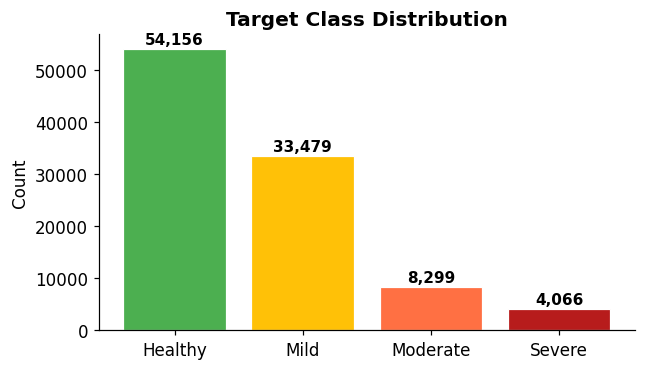

In [7]:
df = df_raw.copy()
TARGET = "sleep_disorder_risk"
CLASS_ORDER = ["Healthy", "Mild", "Moderate", "Severe"]
PALETTE = {"Healthy": "#4CAF50", "Mild": "#FFC107", "Moderate": "#FF7043", "Severe": "#B71C1C"}

fig, ax = plt.subplots(figsize=(6, 3.5))
vc = df[TARGET].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(vc.index, vc.values,
              color=[PALETTE[c] for c in vc.index], edgecolor="white", linewidth=0.8)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 300,
            f"{int(b.get_height()):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Target Class Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("plot_01_class_distribution.png", bbox_inches="tight")
plt.show()


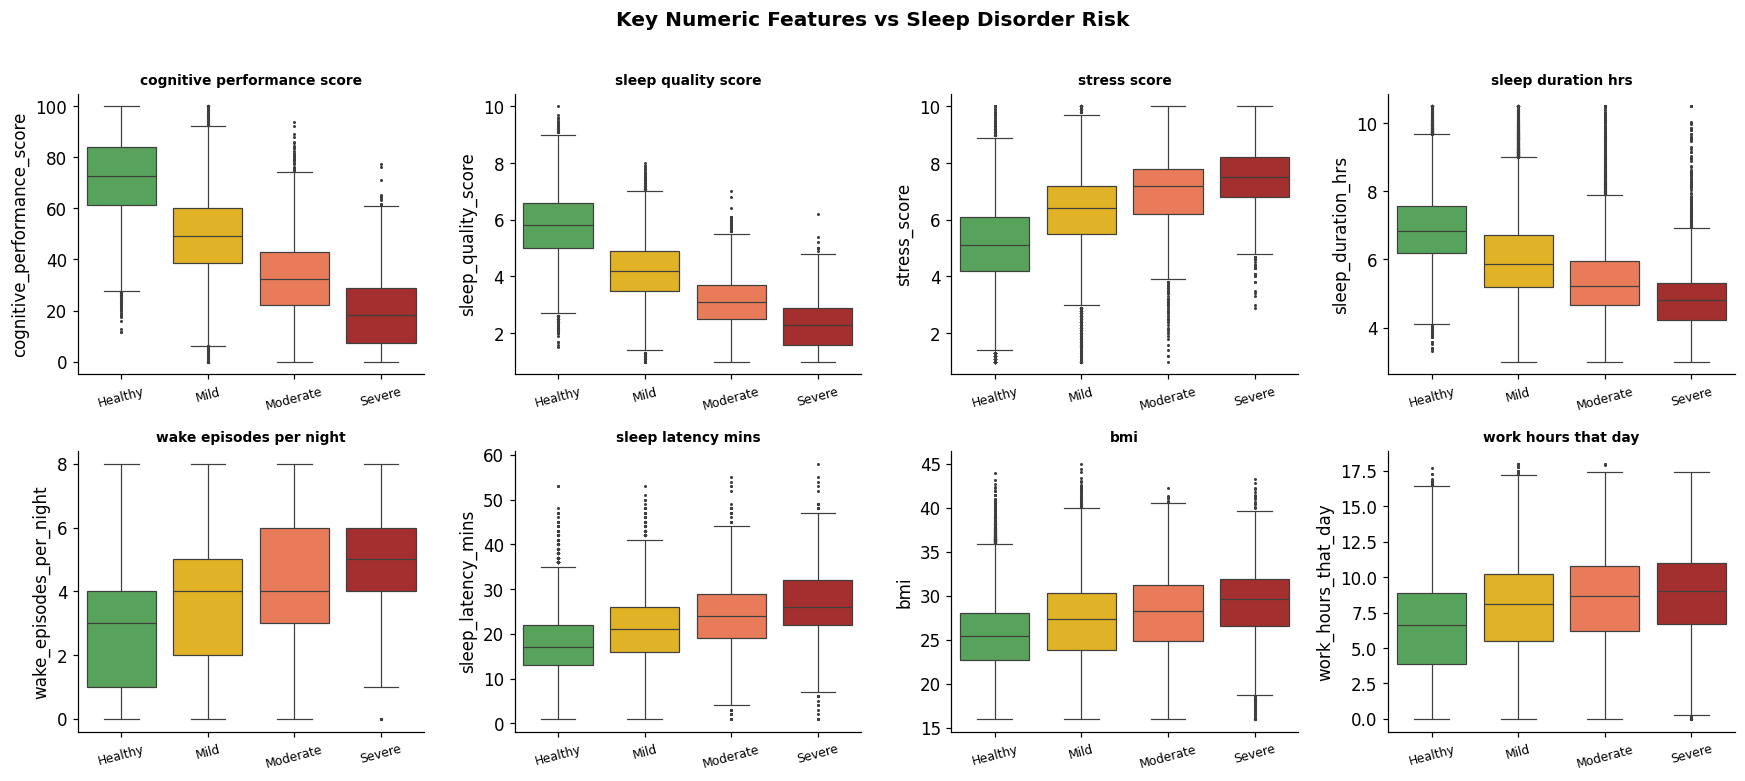

In [8]:
key_num = ["cognitive_performance_score", "sleep_quality_score", "stress_score",
           "sleep_duration_hrs", "wake_episodes_per_night", "sleep_latency_mins",
           "bmi", "work_hours_that_day"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), key_num):
    sns.boxplot(data=df, x=TARGET, y=col, order=CLASS_ORDER, palette=PALETTE, ax=ax,
                linewidth=0.8, fliersize=1)
    ax.set_title(col.replace("_", " "), fontweight="bold", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=8, rotation=15)
plt.suptitle("Key Numeric Features vs Sleep Disorder Risk", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_02_boxplots_by_class.png", bbox_inches="tight")
plt.show()


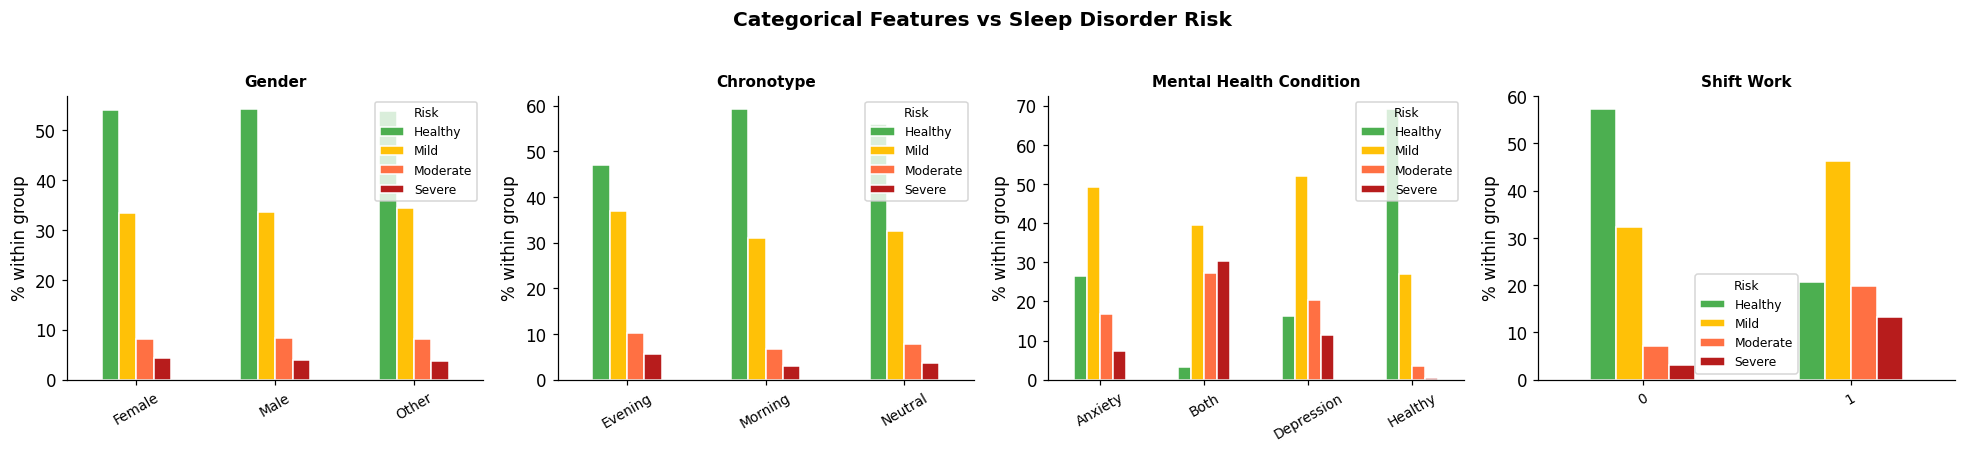

In [9]:
cat_feats = ["gender", "chronotype", "mental_health_condition", "shift_work"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_feats):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index")[CLASS_ORDER] * 100
    ct.plot(kind="bar", ax=ax,
            color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=10)
    ax.set_ylabel("% within group")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.legend(title="Risk", fontsize=8, title_fontsize=8)
plt.suptitle("Categorical Features vs Sleep Disorder Risk", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_03_categorical_vs_target.png", bbox_inches="tight")
plt.show()


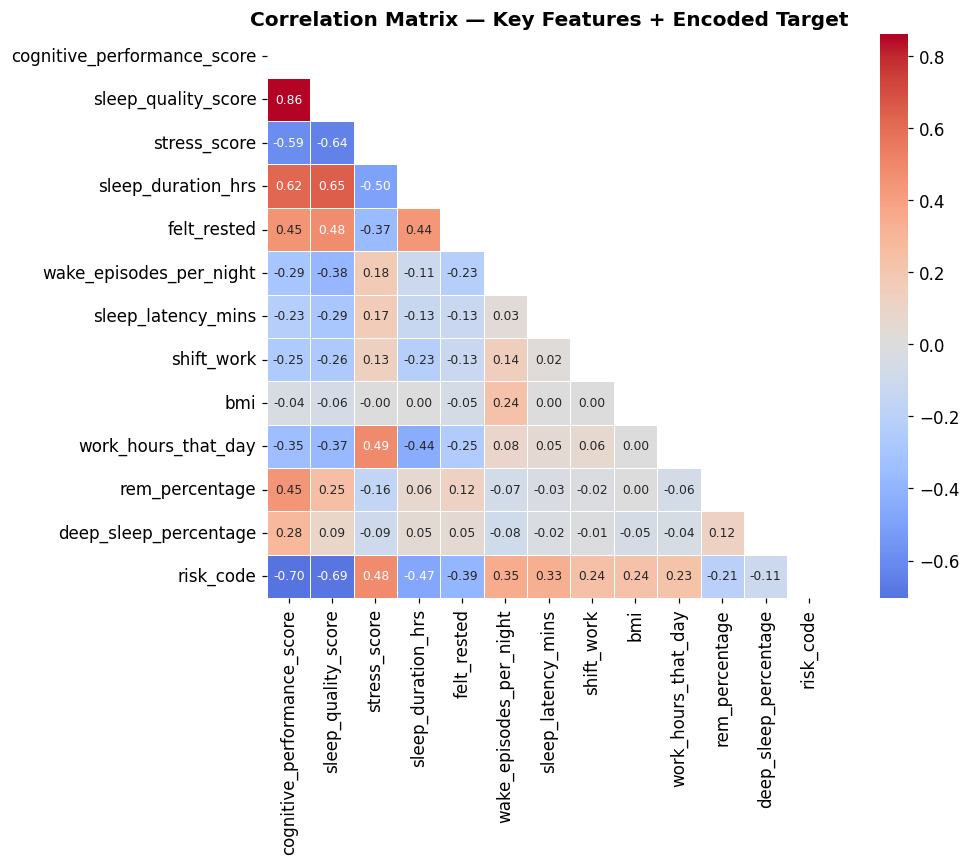

In [ ]:
from sklearn.preprocessing import LabelEncoder
num_for_corr = ["cognitive_performance_score", "sleep_quality_score", "stress_score",
                "sleep_duration_hrs", "felt_rested", "wake_episodes_per_night",
                "sleep_latency_mins", "shift_work", "bmi", "work_hours_that_day",
                "rem_percentage", "deep_sleep_percentage"]

df_corr = df[num_for_corr].copy()
df_corr["risk_code"] = LabelEncoder().fit_transform(df[TARGET])

mask = np.triu(np.ones(df_corr.shape[1], dtype=bool))
plt.figure(figsize=(11, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, linewidths=0.4, square=True, annot_kws={"size": 8})
plt.title("Correlation Matrix — Key Features + Encoded Target", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_04_correlation_heatmap.png", bbox_inches="tight")
plt.show()


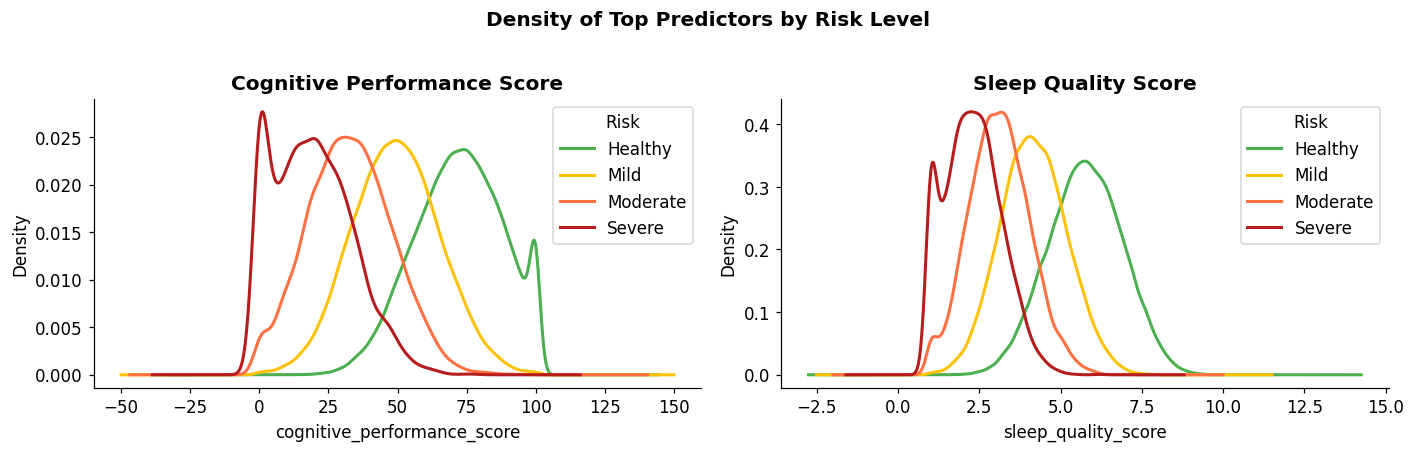

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["cognitive_performance_score", "sleep_quality_score"]):
    for cls in CLASS_ORDER:
        subset = df.loc[df[TARGET] == cls, col]
        subset.plot.kde(ax=ax, label=cls, color=PALETTE[cls], linewidth=2)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel(col)
    ax.legend(title="Risk")
plt.suptitle("Density of Top Predictors by Risk Level", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_05_density_top_predictors.png", bbox_inches="tight")
plt.show()


---
## 4. Preprocessing 

Each ML model relies on data, so the preliminary step is to preprocess the data, so we will perform the following pipeline:

| Step | Reason |
|------|--------|
| **Drop `person_id`** | It is just an ID and doesn't help us predict anything. |
| **Encode Target & Categories** | Models only understand numbers, so we convert text (like *Risk Level*, *Gender*, or *Occupation*) into numerical codes. |
| **Scale Numeric Features** | We put all numbers on the same scale so features with naturally larger numbers don't overpower the others. |
| **Median Imputation** | A safety net to fill in any missing data, ensuring the model won't crash if it sees blank fields in the future. |
| **Keep Binary Features** | Features like *sleep_aid_used* are already 0 or 1, so we leave them exactly as they are. |

In [12]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df_model = df_raw.drop(columns=["person_id"])

le = LabelEncoder()
y = le.fit_transform(df_model[TARGET])
X = df_model.drop(columns=[TARGET])

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("X shape:", X.shape)


Class mapping: {'Healthy': np.int64(0), 'Mild': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}
X shape: (100000, 30)


In [46]:
numeric_features = [
    "age", "bmi", "sleep_duration_hrs", "sleep_quality_score",
    "rem_percentage", "deep_sleep_percentage", "sleep_latency_mins",
    "wake_episodes_per_night", "caffeine_mg_before_bed",
    "alcohol_units_before_bed", "screen_time_before_bed_mins",
    "exercise_day", "steps_that_day", "nap_duration_mins",
    "stress_score", "work_hours_that_day", "heart_rate_resting_bpm",
    "sleep_aid_used", "shift_work", "room_temperature_celsius",
    "weekend_sleep_diff_hrs", "cognitive_performance_score", "felt_rested"
]

nominal_features = [
    "gender", "occupation", "country", "chronotype",
    "mental_health_condition", "season", "day_type"
]

assert set(numeric_features + nominal_features) == set(X.columns), "Column mismatch!"
print(f"Numeric features: {len(numeric_features)}")
print(f"Nominal features: {len(nominal_features)}")


Numeric features: 23
Nominal features: 7


In [47]:
# ── 4.3 Build preprocessing pipeline ────────────────────────────────────────
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

nominal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("nom", nominal_transformer, nominal_features),
])

X_tmp = preprocessor.fit_transform(X.head(100))
print("Preprocessed shape (sample of 100):", X_tmp.shape)
print("23 numeric + OHE-expanded nominials =", X_tmp.shape[1], "features")


Preprocessed shape (sample of 100): (100, 66)
23 numeric + OHE-expanded nominials = 66 features


---
## 5. Train/Test Split with Stratification

The target is imbalanced (Severe = 4 %). Without `stratify=y`, the minority class could be under-represented in the test set, producing unreliable evaluation metrics. 

Ratio:I have choosed to split the dataset as **80 % train / 20 % test**.


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")

# Verify stratification
for split, labels in [("Train", y_train), ("Test", y_test)]:
    counts = pd.Series(labels).map(dict(enumerate(le.classes_))).value_counts()
    pcts   = (counts / counts.sum() * 100).round(1)
    print(f"\n{split}:"); print(pd.DataFrame({"Count": counts, "Pct %": pcts}))

X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)
print(f"\nPreprocessed train shape: {X_train_pp.shape}")


Train: 80,000 rows | Test: 20,000 rows

Train:
          Count  Pct %
Healthy   43325   54.2
Mild      26783   33.5
Moderate   6639    8.3
Severe     3253    4.1

Test:
          Count  Pct %
Healthy   10831   54.2
Mild       6696   33.5
Moderate   1660    8.3
Severe      813    4.1

Preprocessed train shape: (80000, 66)


---
## 6. Performance Metrics

| Metric | Why We Look At It |
|--------|-------------------|
| **F1 Score ** | The best overall metric for our goal. It perfectly balances finding the true at-risk patients (Recall) without giving too many false alarms (Precision). |
| **Accuracy** | Good for a quick overview, but can be misleading because simply guessing "Healthy" every time would still result in high accuracy. |
| **Precision & Recall** | Allows us to zoom in and see exactly which specific risk levels (Healthy, Mild, Moderate, Severe) the model struggles with the most. |
| **Confusion Matrix** | A visual grid that shows us exactly *how* the model gets confused (for example, if it frequently mistakes "Mild" for "Moderate"). |

> **Note:** All of our model training and optimization processes focus specifically on maximizing the **F1 Score**.

In [16]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    """Print train/test metrics, classification report, and confusion matrix."""
    ytr_pred = model.predict(X_tr)
    yte_pred = model.predict(X_te)

    tr_f1  = f1_score(y_tr, ytr_pred, average="macro")
    te_f1  = f1_score(y_te, yte_pred, average="macro")
    tr_acc = accuracy_score(y_tr, ytr_pred)
    te_acc = accuracy_score(y_te, yte_pred)
    gap    = tr_f1 - te_f1
    status = "OK" if gap < 0.05 else ("slight overfit" if gap < 0.15 else "OVERFIT")

    print("=" * 62)
    print(f"  {name}")
    print("=" * 62)
    print(f"  Train   Acc={tr_acc:.3f}   Macro-F1={tr_f1:.3f}")
    print(f"  Test    Acc={te_acc:.3f}   Macro-F1={te_f1:.3f}   [{status}]")
    print()
    print(classification_report(y_te, yte_pred, target_names=le.classes_))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, yte_pred),
                           display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold", fontsize=10)
    plt.tight_layout()
    safe = name[:35].replace(" ", "_")
    plt.savefig(f"plot_cm_{safe}.png", bbox_inches="tight")
    plt.show()

    return {"name": name, "train_f1": tr_f1, "test_f1": te_f1,
            "train_acc": tr_acc, "test_acc": te_acc}

results = []
print("evaluate() helper defined.")


evaluate() helper defined.


---
### 7. Feature Selection (slim Models)

After preparing our data, we ended up with over 30 features. Not all of them are highly useful because some just add noise. I decided to filter the dataset down to the **top 12 most important features**.

**Why do this?**
* **Less Confusion:** It prevents the model from over-learning random noise (overfitting).
* **Faster Training:** Slimmer datasets allow the models to learn and run much faster.
* **Easier to Explain:** It is much easier to explain a clinical decision based on 12 key factors rather than 30+.

**How we chose the Top 12:**
Instead of guessing, we used two mathematical checks to find the best predictors:
1. **Direct Impact:** We measured how strongly each individual feature is linked to the sleep disorder risk.
2. **Teamwork:** We ran an initial test model to see which features work the best *together* to make accurate predictions.

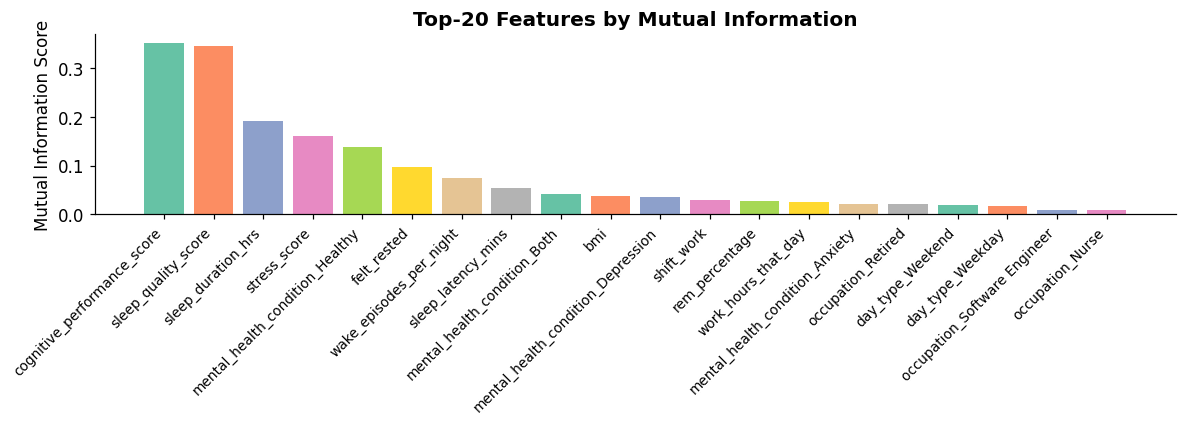

Top 12 features:
cognitive_performance_score           0.352015
sleep_quality_score                   0.346864
sleep_duration_hrs                    0.191942
stress_score                          0.159992
mental_health_condition_Healthy       0.138609
felt_rested                           0.098036
wake_episodes_per_night               0.075260
sleep_latency_mins                    0.053788
mental_health_condition_Both          0.040789
bmi                                   0.037782
mental_health_condition_Depression    0.034923
shift_work                            0.028865


In [53]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

idx_sub = np.random.choice(len(X_train_pp), size=20_000, replace=False)
mi = mutual_info_classif(X_train_pp[idx_sub], y_train[idx_sub], random_state=SEED)

ohe_names = (preprocessor.named_transformers_["nom"]["encoder"]
             .get_feature_names_out(nominal_features).tolist())
all_feature_names = numeric_features + ohe_names

mi_series = pd.Series(mi, index=all_feature_names).sort_values(ascending=False)

top20 = mi_series.head(20)
plt.figure(figsize=(11, 4))
plt.bar(top20.index, top20.values, color=sns.color_palette("Set2", 20))
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Mutual Information Score")
plt.title("Top-20 Features by Mutual Information", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_06_mi_scores.png", bbox_inches="tight")
plt.show()

print("Top 12 features:")
print(mi_series.head(12).to_string())


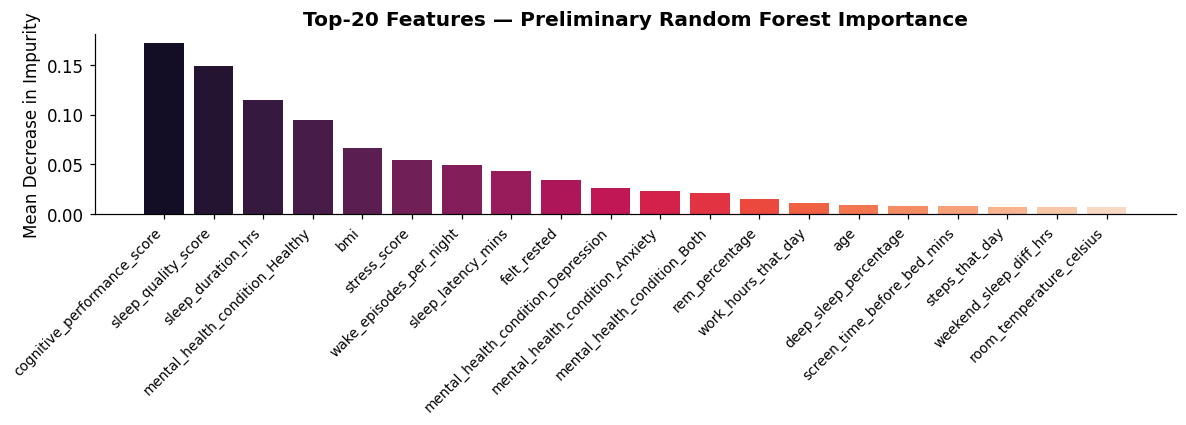

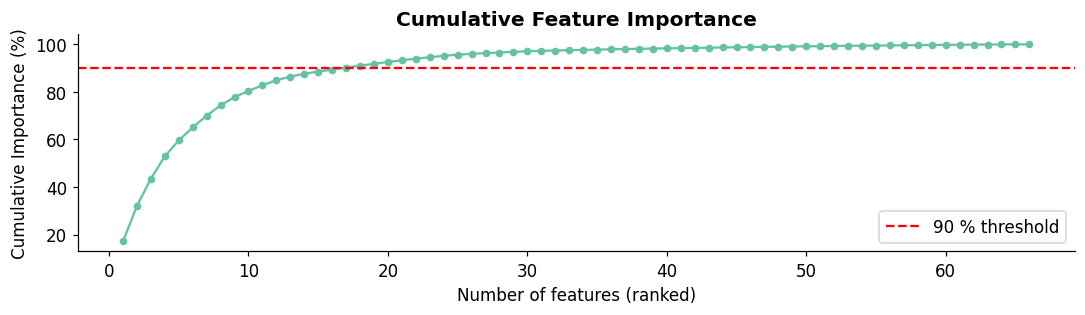

In [ ]:
rf_pre = RandomForestClassifier(n_estimators=100, max_depth=10,
                                random_state=SEED, n_jobs=-1)
rf_pre.fit(X_train_pp[idx_sub], y_train[idx_sub])
rf_imp = pd.Series(rf_pre.feature_importances_,
                   index=all_feature_names).sort_values(ascending=False)

top20_rf = rf_imp.head(20)
plt.figure(figsize=(11, 4))
plt.bar(top20_rf.index, top20_rf.values, color=sns.color_palette("rocket", 20))
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Mean Decrease in Impurity")
plt.title("Top-20 Features — Preliminary Random Forest Importance", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_07_rf_prelim_importance.png", bbox_inches="tight")
plt.show()

cum = rf_imp.cumsum() / rf_imp.sum() * 100
plt.figure(figsize=(10, 3))
plt.plot(range(1, len(cum)+1), cum.values, "o-", markersize=4)
plt.axhline(90, color="red", linestyle="--", label="90 % threshold")
plt.xlabel("Number of features (ranked)")
plt.ylabel("Cumulative Importance (%)")
plt.title("Cumulative Feature Importance", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig("plot_08_cumulative_importance.png", bbox_inches="tight")
plt.show()


In [ ]:
TOP_K = 12
selector = SelectKBest(mutual_info_classif, k=TOP_K)
X_train_sel = selector.fit_transform(X_train_pp[idx_sub], y_train[idx_sub])

X_train_sel = selector.transform(X_train_pp)
X_test_sel  = selector.transform(X_test_pp)

selected_names = [n for n, m in zip(all_feature_names, selector.get_support()) if m]
print(f"SelectKBest top-{TOP_K} features:")
for i, fn in enumerate(selected_names, 1):
    print(f"  {i:2d}. {fn}")


SelectKBest top-12 features:
   1. bmi
   2. sleep_duration_hrs
   3. sleep_quality_score
   4. sleep_latency_mins
   5. wake_episodes_per_night
   6. stress_score
   7. cognitive_performance_score
   8. felt_rested
   9. mental_health_condition_Anxiety
  10. mental_health_condition_Both
  11. mental_health_condition_Depression
  12. mental_health_condition_Healthy


---
## 8. Model Building, Evaluation & Optimisation

For **each model** we follow this process:
1. **Baseline** - default hyperparameters, full feature set
2. **Hyperparameter search** - GridSearchCV/RandomizedSearchCV on train set only (5-fold stratified CV)
3. **Under/overfitting analysis** - learning curves and key-parameter sweep
4. **Test set evaluation** - never used during tuning
5. **Slim variant** - same best params, but top-12 features


### 8a. Decision Tree Classifier


Baseline Decission Tree

  Decision Tree (baseline)
  Train   Acc=1.000   Macro-F1=1.000
  Test    Acc=0.905   Macro-F1=0.794   [OVERFIT]

              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98     10831
        Mild       0.89      0.89      0.89      6696
    Moderate       0.60      0.58      0.59      1660
      Severe       0.72      0.72      0.72       813

    accuracy                           0.91     20000
   macro avg       0.79      0.79      0.79     20000
weighted avg       0.90      0.91      0.90     20000



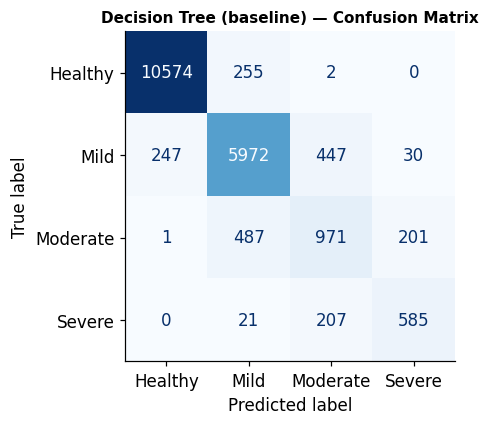

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

dt_base = DecisionTreeClassifier(random_state=SEED)
dt_base.fit(X_train_pp, y_train)
r = evaluate(dt_base, X_train_pp, y_train, X_test_pp, y_test, "Decision Tree (baseline)")
results.append(r)


Apply grid search, to search for the best decision tree

In [54]:
dt_grid = {
    "max_depth":         [5, 10, 15, 20, None],
    "min_samples_leaf":  [1, 5, 20, 50],
    "criterion":         ["gini", "entropy"],
    "class_weight":      [None, "balanced"],
}

dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                     dt_grid, scoring="f1_macro", cv=cv5, n_jobs=-1, verbose=1)
dt_gs.fit(X_train_pp, y_train)
print("Best params:", dt_gs.best_params_)
print(f"Best CV F1: {dt_gs.best_score_:.4f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 20}
Best CV F1: 0.7871


Predict using the selected DT

  Decision Tree (tuned)
  Train   Acc=0.920   Macro-F1=0.844
  Test    Acc=0.893   Macro-F1=0.791   [slight overfit]

              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96     10831
        Mild       0.87      0.87      0.87      6696
    Moderate       0.62      0.60      0.61      1660
      Severe       0.77      0.68      0.72       813

    accuracy                           0.89     20000
   macro avg       0.80      0.78      0.79     20000
weighted avg       0.89      0.89      0.89     20000



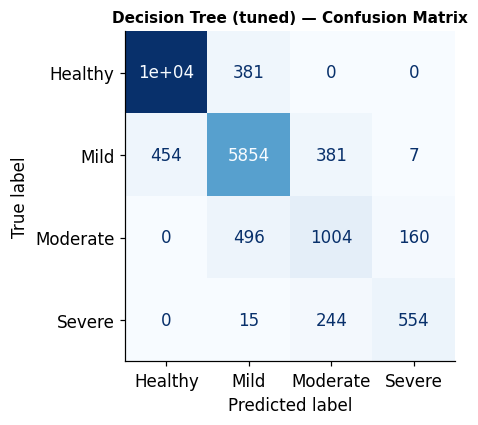

In [ ]:
dt_best = dt_gs.best_estimator_
r = evaluate(dt_best, X_train_pp, y_train, X_test_pp, y_test, "Decision Tree")
results.append(r)


Top 3 levels of the selected DT (Visualization)

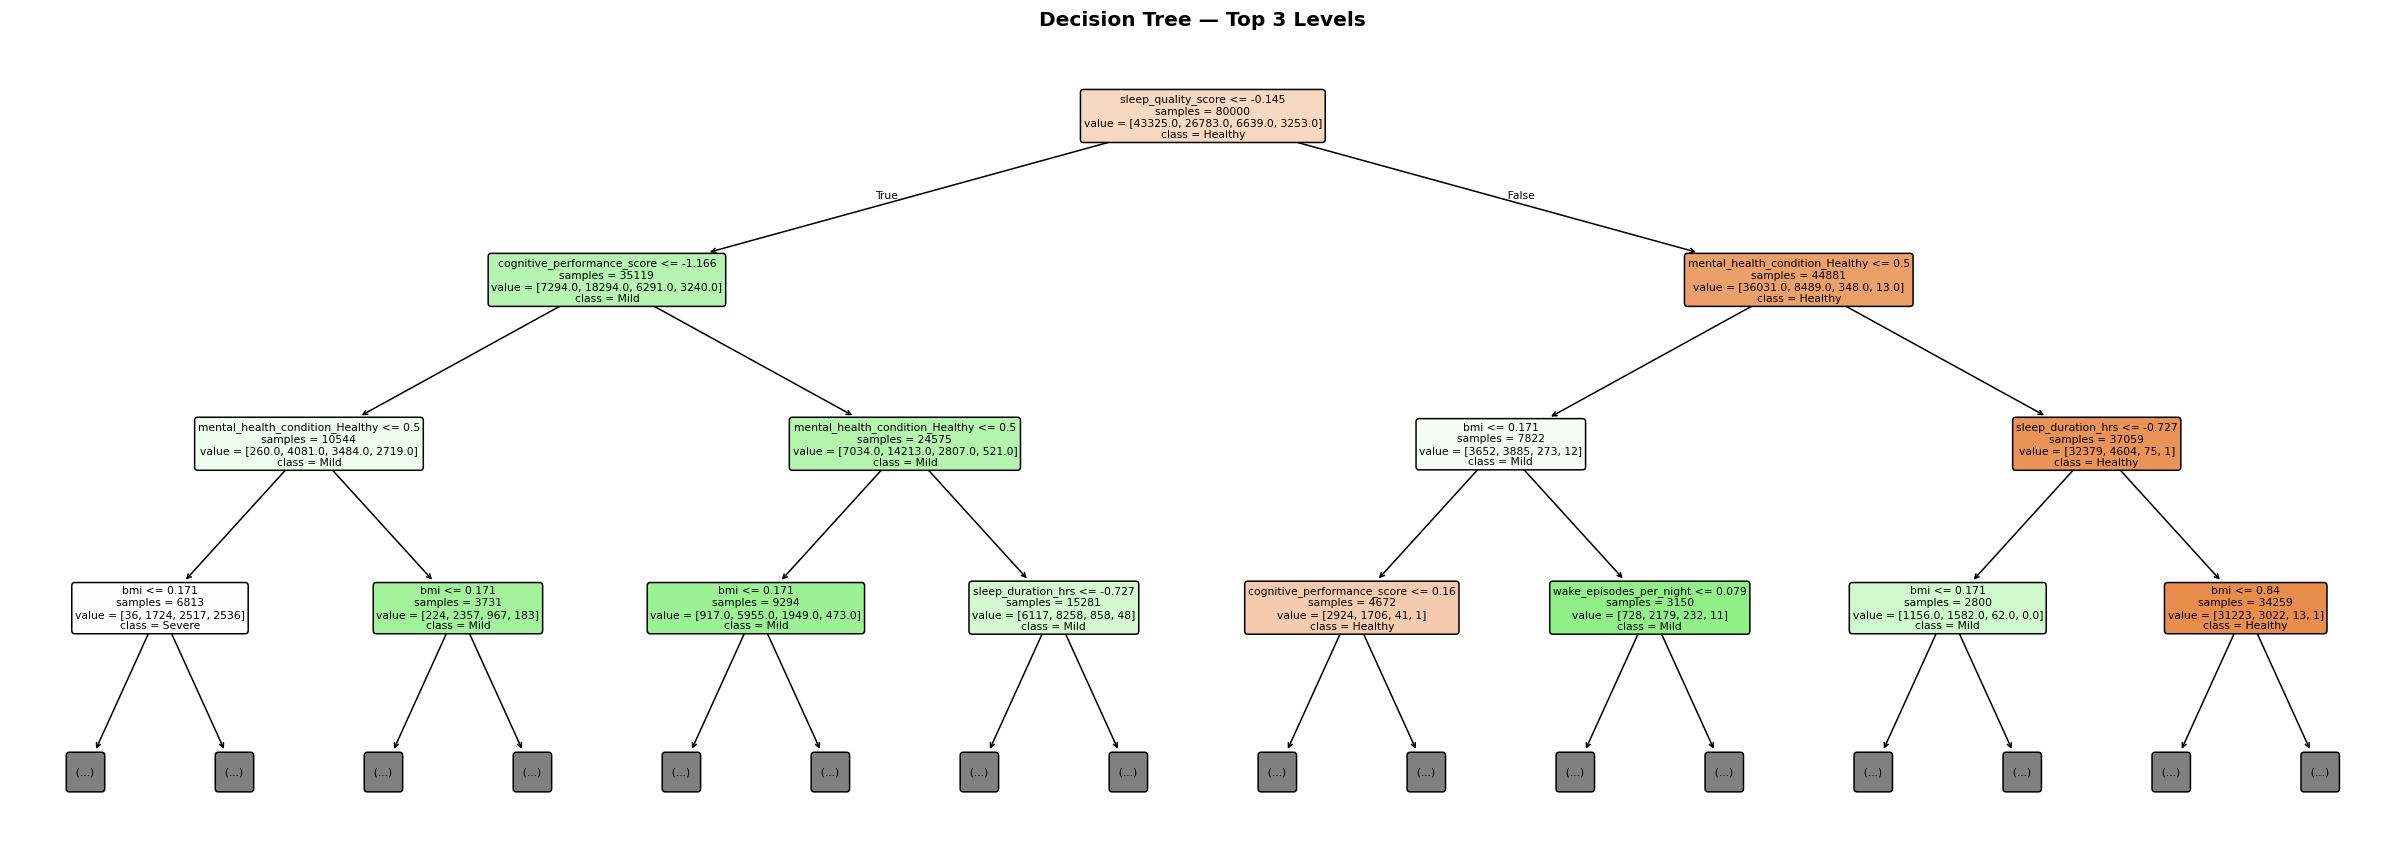

In [ ]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_best, feature_names=all_feature_names, class_names=le.classes_,
          filled=True, max_depth=3, fontsize=7, ax=ax, rounded=True, impurity=False)
plt.title("Decision Tree — Top 3 Levels", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_09_dt_tree.png", bbox_inches="tight")
plt.show()


Now we are trying to explore the best depth, in order to prevent overfitting/underfitting

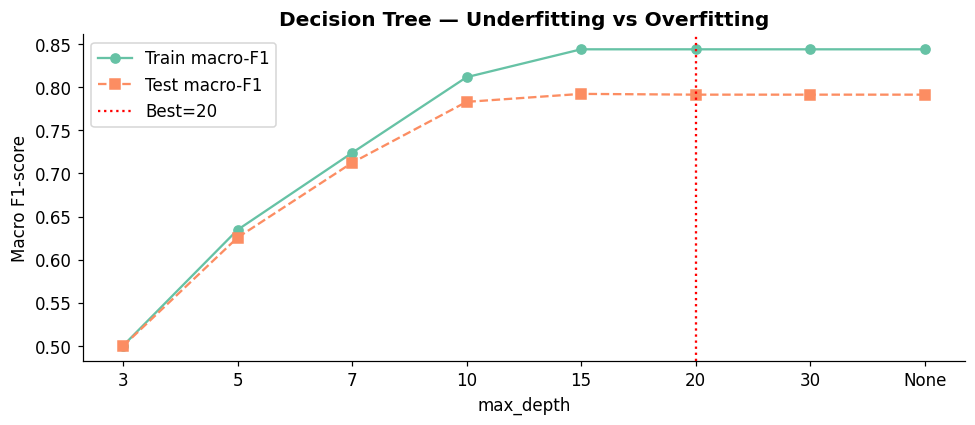

In [ ]:
depths = [3, 5, 7, 10, 15, 20, 30, None]
tr_f1s, te_f1s, labels = [], [], []
other = {k: v for k, v in dt_gs.best_params_.items() if k != "max_depth"}
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=SEED, **other)
    m.fit(X_train_pp, y_train)
    tr_f1s.append(f1_score(y_train, m.predict(X_train_pp), average="macro"))
    te_f1s.append(f1_score(y_test,  m.predict(X_test_pp),  average="macro"))
    labels.append(str(d))

plt.figure(figsize=(9, 4))
plt.plot(labels, tr_f1s, "o-", label="Train macro-F1")
plt.plot(labels, te_f1s, "s--", label="Test macro-F1")
best_lbl = str(dt_gs.best_params_["max_depth"])
if best_lbl in labels:
    plt.axvline(labels.index(best_lbl), color="red", linestyle=":", label=f"Best={best_lbl}")
plt.xlabel("max_depth")
plt.ylabel("Macro F1-score")
plt.title("Decision Tree — Underfitting vs Overfitting", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig("plot_10_dt_depth_curve.png", bbox_inches="tight")
plt.show()


Evaluation of the slim DT, using the selected arguments

  Decision Tree (slim top-12)
  Train   Acc=0.908   Macro-F1=0.830
  Test    Acc=0.887   Macro-F1=0.791   [OK]

              precision    recall  f1-score   support

     Healthy       0.94      0.97      0.96     10831
        Mild       0.87      0.85      0.86      6696
    Moderate       0.62      0.61      0.61      1660
      Severe       0.78      0.70      0.74       813

    accuracy                           0.89     20000
   macro avg       0.80      0.78      0.79     20000
weighted avg       0.89      0.89      0.89     20000



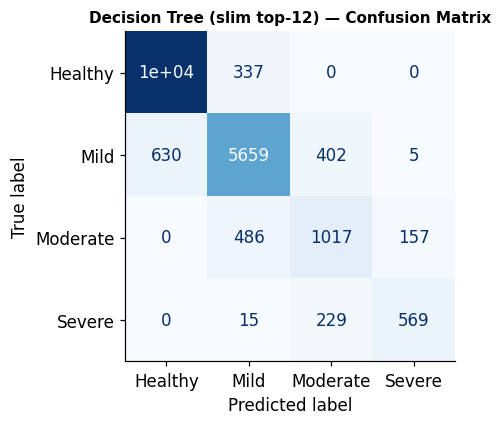

In [25]:
# ── Slim DT ──────────────────────────────────────────────────────────────────
dt_slim = DecisionTreeClassifier(random_state=SEED, **dt_gs.best_params_)
dt_slim.fit(X_train_sel, y_train)
r = evaluate(dt_slim, X_train_sel, y_train, X_test_sel, y_test,
             f"Decision Tree (slim top-{TOP_K})")
results.append(r)


### 8b. Naive Bayes Classifier

**Why Naive Bayes?**  
Gaussian Naive Bayes is a fast, interpretable probabilistic classifier. It assumes conditional independence between features given the class and models each feature with a Gaussian distribution. After StandardScaler, the Gaussian assumption is reasonably met for continuous features. It scales to 100 k rows instantly, has no risk of infinite loops, and its sole hyperparameter (`var_smoothing`) is trivial to tune.


  Naive Bayes (baseline)
  Train   Acc=0.695   Macro-F1=0.570
  Test    Acc=0.697   Macro-F1=0.573   [OK]

              precision    recall  f1-score   support

     Healthy       0.87      0.84      0.85     10831
        Mild       0.63      0.54      0.58      6696
    Moderate       0.27      0.35      0.31      1660
      Severe       0.41      0.84      0.55       813

    accuracy                           0.70     20000
   macro avg       0.55      0.64      0.57     20000
weighted avg       0.72      0.70      0.70     20000



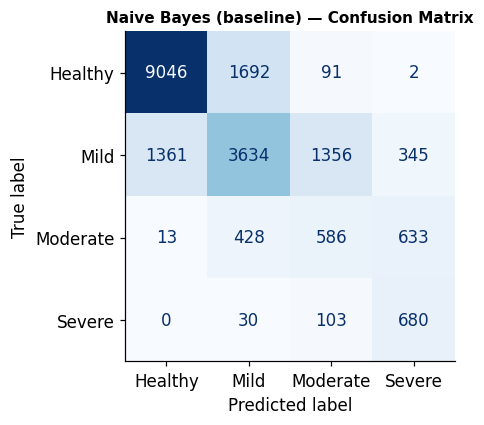

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_base = GaussianNB()
gnb_base.fit(X_train_pp, y_train)
r = evaluate(gnb_base, X_train_pp, y_train, X_test_pp, y_test, "Naive Bayes (baseline)")
results.append(r)


In [55]:
gnb_grid = {"var_smoothing": np.logspace(-11, -1, 13)}

gnb_gs = GridSearchCV(GaussianNB(), gnb_grid, scoring="f1_macro",
                      cv=cv5, n_jobs=-1, verbose=0)
gnb_gs.fit(X_train_pp, y_train)
print("Best params:", gnb_gs.best_params_)
print(f"Best CV macro-F1: {gnb_gs.best_score_:.4f}")


Best params: {'var_smoothing': np.float64(0.1)}
Best CV macro-F1: 0.6350


  Naive Bayes (tuned)
  Train   Acc=0.742   Macro-F1=0.637
  Test    Acc=0.741   Macro-F1=0.631   [OK]

              precision    recall  f1-score   support

     Healthy       0.87      0.86      0.86     10831
        Mild       0.66      0.64      0.65      6696
    Moderate       0.37      0.39      0.38      1660
      Severe       0.56      0.73      0.63       813

    accuracy                           0.74     20000
   macro avg       0.61      0.65      0.63     20000
weighted avg       0.74      0.74      0.74     20000



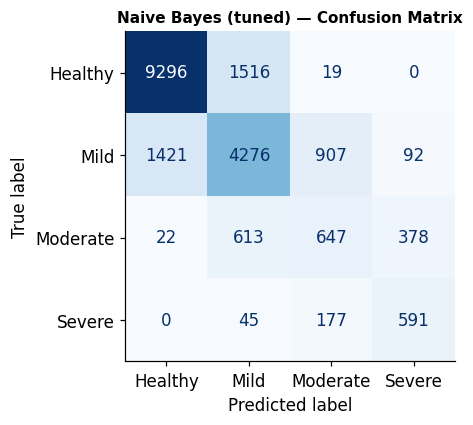

In [28]:
gnb_best = gnb_gs.best_estimator_
r = evaluate(gnb_best, X_train_pp, y_train, X_test_pp, y_test, "Naive Bayes (tuned)")
results.append(r)


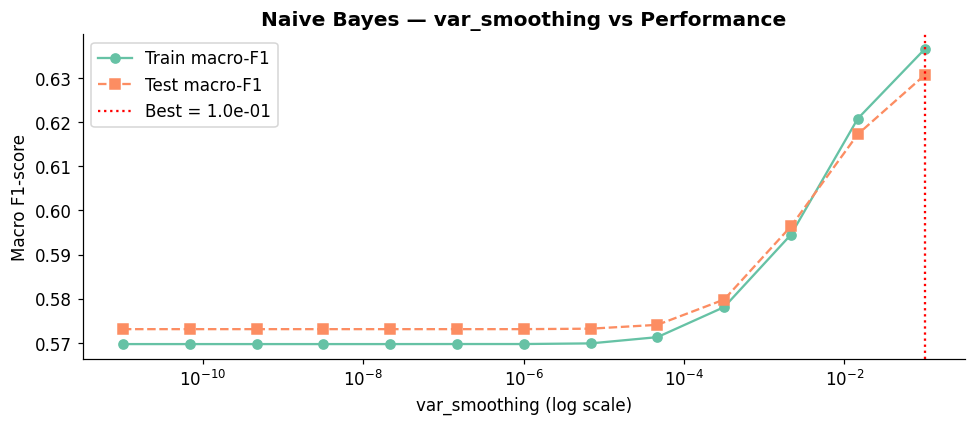

In [56]:
sv_vals = np.logspace(-11, -1, 13)
tr_s, te_s = [], []
for sv in sv_vals:
    m = GaussianNB(var_smoothing=sv)
    m.fit(X_train_pp, y_train)
    tr_s.append(f1_score(y_train, m.predict(X_train_pp), average="macro"))
    te_s.append(f1_score(y_test,  m.predict(X_test_pp),  average="macro"))

plt.figure(figsize=(9, 4))
plt.semilogx(sv_vals, tr_s, "o-",  label="Train macro-F1")
plt.semilogx(sv_vals, te_s, "s--", label="Test macro-F1")
plt.axvline(gnb_gs.best_params_["var_smoothing"], color="red",
            linestyle=":", label=f"Best = {gnb_gs.best_params_['var_smoothing']:.1e}")
plt.xlabel("var_smoothing (log scale)")
plt.ylabel("Macro F1-score")
plt.title("Naive Bayes — var_smoothing vs Performance", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig("plot_11_nb_smoothing.png", bbox_inches="tight")
plt.show()


  Naive Bayes (slim top-12)
  Train   Acc=0.767   Macro-F1=0.654
  Test    Acc=0.763   Macro-F1=0.644   [OK]

              precision    recall  f1-score   support

     Healthy       0.88      0.87      0.88     10831
        Mild       0.69      0.69      0.69      6696
    Moderate       0.40      0.36      0.38      1660
      Severe       0.58      0.69      0.63       813

    accuracy                           0.76     20000
   macro avg       0.64      0.65      0.64     20000
weighted avg       0.76      0.76      0.76     20000



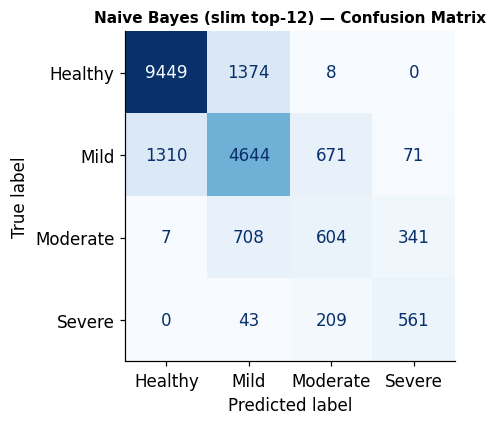

In [30]:
# ── Slim NB ───────────────────────────────────────────────────────────────────
gnb_slim = GaussianNB(**gnb_gs.best_params_)
gnb_slim.fit(X_train_sel, y_train)
r = evaluate(gnb_slim, X_train_sel, y_train, X_test_sel, y_test,
             f"Naive Bayes (slim top-{TOP_K})")
results.append(r)


### 8c. Random Forest (Ensemble Method)


  Random Forest (baseline)
  Train   Acc=1.000   Macro-F1=1.000
  Test    Acc=0.896   Macro-F1=0.794   [OVERFIT]

              precision    recall  f1-score   support

     Healthy       0.95      0.97      0.96     10831
        Mild       0.85      0.91      0.87      6696
    Moderate       0.69      0.50      0.58      1660
      Severe       0.85      0.70      0.76       813

    accuracy                           0.90     20000
   macro avg       0.83      0.77      0.79     20000
weighted avg       0.89      0.90      0.89     20000



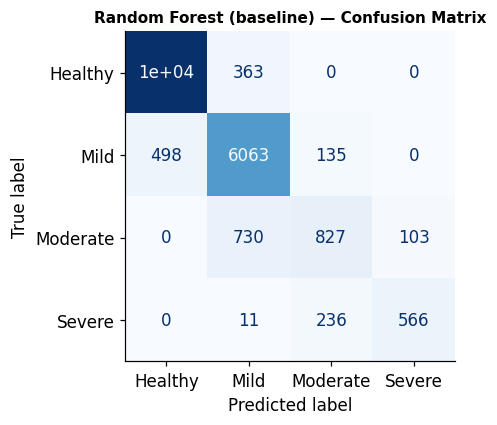

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_base.fit(X_train_pp, y_train)
r = evaluate(rf_base, X_train_pp, y_train, X_test_pp, y_test, "Random Forest (baseline)")
results.append(r)


In [ ]:
from scipy.stats import randint

rf_dist = {
    "n_estimators":      randint(100, 400),
    "max_depth":         [None, 10, 20, 30],
    "min_samples_leaf":  randint(1, 20),
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
    "class_weight":      [None, "balanced", "balanced_subsample"],
}

rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_dist, n_iter=30, scoring="f1_macro",
    cv=cv5, n_jobs=-1, random_state=SEED, verbose=1)
rf_rs.fit(X_train_pp, y_train)
print("Best params:", rf_rs.best_params_)
print(f"Best CV macro-F1: {rf_rs.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 4, 'n_estimators': 251}
Best CV macro-F1: 0.8248


  Random Forest (tuned)
  Train   Acc=0.983   Macro-F1=0.971
  Test    Acc=0.917   Macro-F1=0.831   [slight overfit]

              precision    recall  f1-score   support

     Healthy       0.97      0.97      0.97     10831
        Mild       0.91      0.89      0.90      6696
    Moderate       0.65      0.71      0.68      1660
      Severe       0.80      0.75      0.77       813

    accuracy                           0.92     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.92      0.92      0.92     20000



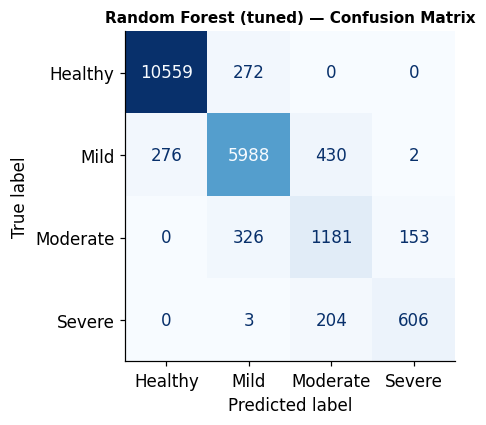

In [34]:
rf_best = rf_rs.best_estimator_
r = evaluate(rf_best, X_train_pp, y_train, X_test_pp, y_test, "Random Forest (tuned)")
results.append(r)


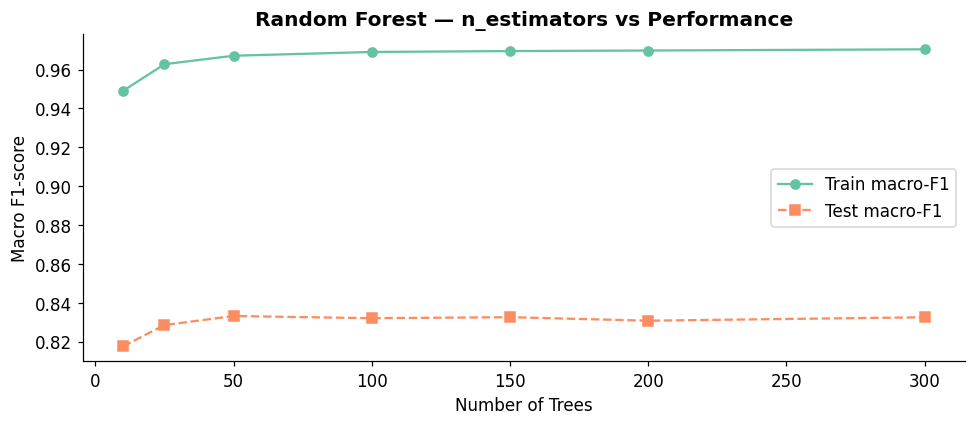

In [ ]:
n_trees_list = [10, 25, 50, 100, 150, 200, 300]
tr_n, te_n = [], []
best_rf_p = {k: v for k, v in rf_rs.best_params_.items() if k != "n_estimators"}
for n in n_trees_list:
    m = RandomForestClassifier(n_estimators=n, random_state=SEED,
                               n_jobs=-1, **best_rf_p)
    m.fit(X_train_pp, y_train)
    tr_n.append(f1_score(y_train, m.predict(X_train_pp), average="macro"))
    te_n.append(f1_score(y_test,  m.predict(X_test_pp),  average="macro"))

plt.figure(figsize=(9, 4))
plt.plot(n_trees_list, tr_n, "o-",  label="Train macro-F1")
plt.plot(n_trees_list, te_n, "s--", label="Test macro-F1")
plt.xlabel("Number of Trees")
plt.ylabel("Macro F1-score")
plt.title("Random Forest — n_estimators vs Performance", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig("plot_12_rf_n_trees.png", bbox_inches="tight")
plt.show()


## Adaboost classifier (ensemble method)

  AdaBoost
  Train   Acc=0.724   Macro-F1=0.519
  Test    Acc=0.723   Macro-F1=0.516   [OK]

              precision    recall  f1-score   support

     Healthy       0.92      0.71      0.80     10831
        Mild       0.60      0.86      0.71      6696
    Moderate       0.50      0.64      0.56      1660
      Severe       0.00      0.00      0.00       813

    accuracy                           0.72     20000
   macro avg       0.50      0.55      0.52     20000
weighted avg       0.74      0.72      0.72     20000



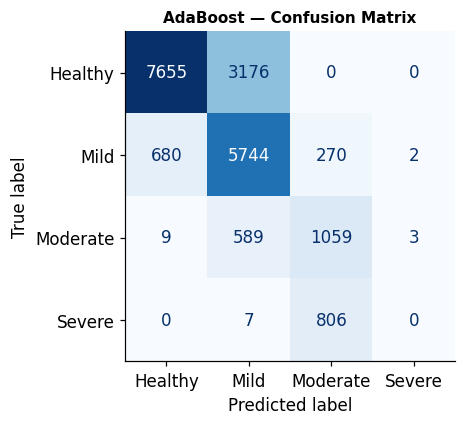

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=SEED)
ada.fit(X_train_pp, y_train)
r = evaluate(ada, X_train_pp, y_train, X_test_pp, y_test, "AdaBoost")
results.append(r)


## Random forests

  Random Forest (slim top-12)
  Train   Acc=0.961   Macro-F1=0.938
  Test    Acc=0.897   Macro-F1=0.815   [slight overfit]

              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96     10831
        Mild       0.89      0.85      0.87      6696
    Moderate       0.62      0.71      0.66      1660
      Severe       0.78      0.76      0.77       813

    accuracy                           0.90     20000
   macro avg       0.81      0.82      0.82     20000
weighted avg       0.90      0.90      0.90     20000



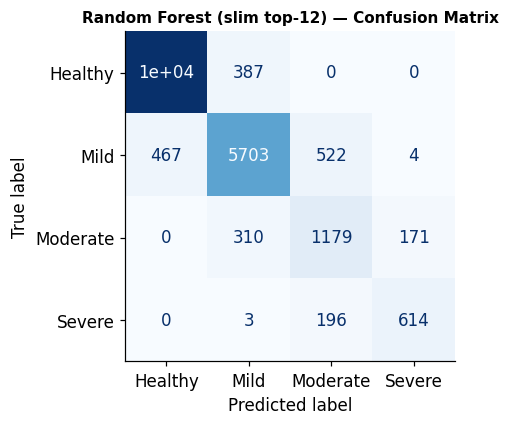

In [ ]:
rf_slim = RandomForestClassifier(random_state=SEED, n_jobs=-1, **rf_rs.best_params_)
rf_slim.fit(X_train_sel, y_train)
r = evaluate(rf_slim, X_train_sel, y_train, X_test_sel, y_test,
             f"Random Forest (slim top-{TOP_K})")
results.append(r)


---
## 9. Feature Engineering & Re-evaluation

We propose **5 new features** grounded in sleep-science research and EDA observations:

| New Feature | Formula | Rationale |
|-------------|---------|-----------|
| `sleep_efficiency` | `(sleep_duration_hrs × sleep_quality_score) / 10` | Combined quality-duration score normalised to [0, ~10]; better proxy for restorative sleep than either alone |
| `total_sleep_disruption` | `sleep_latency_mins + wake_episodes_per_night × 10` | Penalises both difficulty falling asleep and fragmented sleep |
| `pre_bed_stimulant_load` | `caffeine_mg_before_bed / 100 + alcohol_units_before_bed` | Combined stimulant/sedative burden before sleep |
| `cognitive_stress_ratio` | `cognitive_performance_score / (stress_score + 1)` | High cognitive score with low stress → healthy; ratio captures the balance |
| `screen_caffeine_index` | `screen_time_before_bed_mins × (1 + caffeine_mg_before_bed / 200)` | Interaction between two arousal-promoting pre-bed behaviours |


In [ ]:
def add_features(df_in):
    d = df_in.copy()
    d["sleep_efficiency"]         = (d["sleep_duration_hrs"] * d["sleep_quality_score"]) / 10
    d["total_sleep_disruption"]   = d["sleep_latency_mins"] + d["wake_episodes_per_night"] * 10
    d["pre_bed_stimulant_load"]   = d["caffeine_mg_before_bed"] / 100 + d["alcohol_units_before_bed"]
    d["cognitive_stress_ratio"]   = d["cognitive_performance_score"] / (d["stress_score"] + 1)
    d["screen_caffeine_index"]    = (d["screen_time_before_bed_mins"]
                                     * (1 + d["caffeine_mg_before_bed"] / 200))
    return d

new_features = ["sleep_efficiency", "total_sleep_disruption",
                "pre_bed_stimulant_load", "cognitive_stress_ratio",
                "screen_caffeine_index"]

X_eng = add_features(X)

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eng, y, test_size=0.20, random_state=SEED, stratify=y)

numeric_features_e = numeric_features + new_features

preprocessor_e = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scl", StandardScaler())]), numeric_features_e),
    ("nom", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     nominal_features),
])

X_train_e_pp = preprocessor_e.fit_transform(X_train_e)
X_test_e_pp  = preprocessor_e.transform(X_test_e)
print("Engineered feature matrix shape:", X_train_e_pp.shape)


Engineered feature matrix shape: (80000, 71)


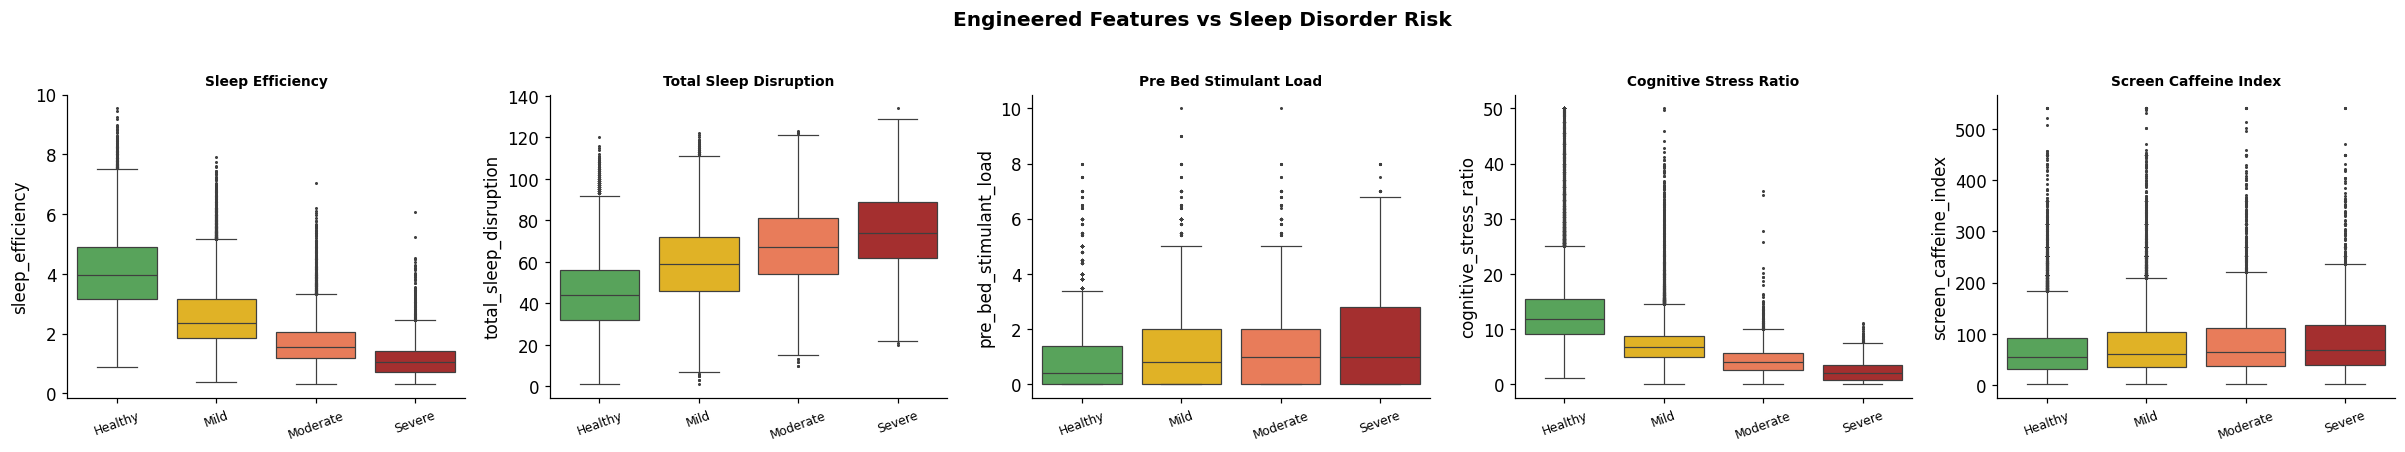

In [ ]:
df_viz = add_features(X)
df_viz[TARGET] = df_model[TARGET].values

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, new_features):
    sns.boxplot(data=df_viz, x=TARGET, y=col, order=CLASS_ORDER,
                palette=PALETTE, ax=ax, linewidth=0.8, fliersize=1)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)
plt.suptitle("Engineered Features vs Sleep Disorder Risk", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_13_engineered_features.png", bbox_inches="tight")
plt.show()


  DT (tuned + engineered)
  Train   Acc=0.919   Macro-F1=0.845
  Test    Acc=0.894   Macro-F1=0.794   [slight overfit]

              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96     10831
        Mild       0.87      0.88      0.87      6696
    Moderate       0.63      0.59      0.61      1660
      Severe       0.76      0.70      0.73       813

    accuracy                           0.89     20000
   macro avg       0.80      0.78      0.79     20000
weighted avg       0.89      0.89      0.89     20000



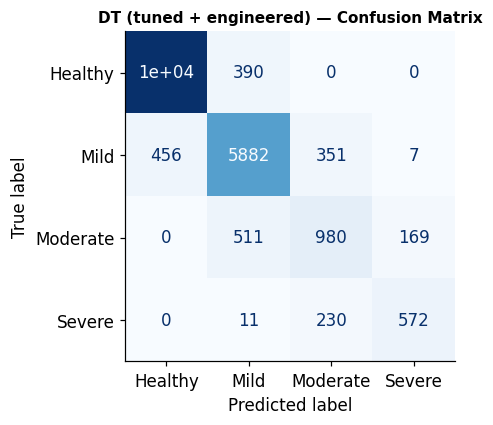

  Naive Bayes (tuned + engineered)
  Train   Acc=0.715   Macro-F1=0.614
  Test    Acc=0.716   Macro-F1=0.612   [OK]

              precision    recall  f1-score   support

     Healthy       0.88      0.82      0.85     10831
        Mild       0.63      0.62      0.62      6696
    Moderate       0.33      0.43      0.37      1660
      Severe       0.51      0.75      0.61       813

    accuracy                           0.72     20000
   macro avg       0.59      0.65      0.61     20000
weighted avg       0.74      0.72      0.72     20000



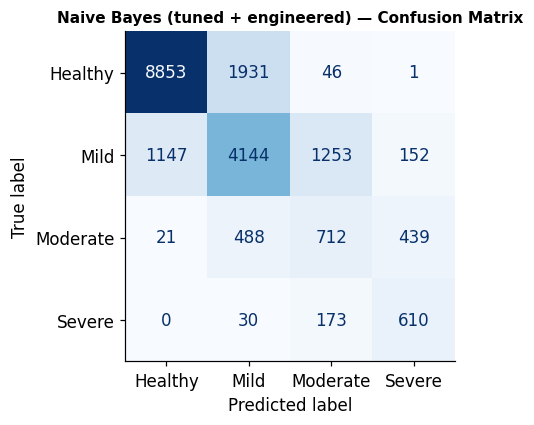

  RF (tuned + engineered)
  Train   Acc=0.982   Macro-F1=0.969
  Test    Acc=0.913   Macro-F1=0.827   [slight overfit]

              precision    recall  f1-score   support

     Healthy       0.97      0.97      0.97     10831
        Mild       0.91      0.89      0.90      6696
    Moderate       0.64      0.71      0.67      1660
      Severe       0.80      0.74      0.77       813

    accuracy                           0.91     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.92      0.91      0.91     20000



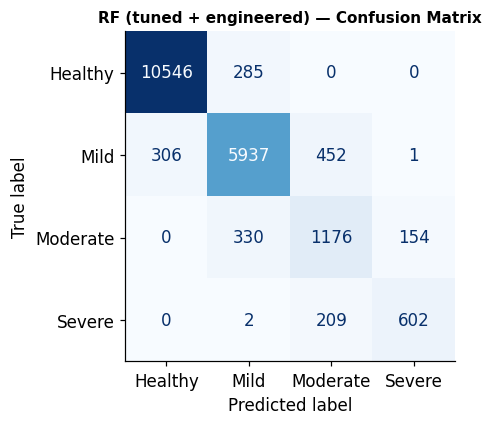

In [ ]:
dt_eng = DecisionTreeClassifier(random_state=SEED, **dt_gs.best_params_)
dt_eng.fit(X_train_e_pp, y_train_e)
r = evaluate(dt_eng, X_train_e_pp, y_train_e, X_test_e_pp, y_test_e,
             "DT (feature eng)")
results.append(r)

gnb_eng = GaussianNB(**gnb_gs.best_params_)
gnb_eng.fit(X_train_e_pp, y_train_e)
r = evaluate(gnb_eng, X_train_e_pp, y_train_e, X_test_e_pp, y_test_e,
             "Naive Bayes (feature eng)")
results.append(r)

rf_eng = RandomForestClassifier(random_state=SEED, n_jobs=-1, **rf_rs.best_params_)
rf_eng.fit(X_train_e_pp, y_train_e)
r = evaluate(rf_eng, X_train_e_pp, y_train_e, X_test_e_pp, y_test_e,
             "RF (feature eng)")
results.append(r)


---
## 10. Final Comparison & Conclusions


In [ ]:
df_res = pd.DataFrame(results)
df_res["overfit_gap"] = (df_res["train_f1"] - df_res["test_f1"]).round(4)
df_res = df_res.sort_values("test_f1", ascending=False).reset_index(drop=True)
df_res.index += 1
print(df_res[["name","train_f1","test_f1","test_acc","overfit_gap"]].to_string())


                                name  train_f1   test_f1  test_acc  overfit_gap
1              Random Forest (tuned)  0.970636  0.831475   0.91670       0.1392
2            RF (tuned + engineered)  0.968597  0.827088   0.91305       0.1415
3        Random Forest (slim top-12)  0.938132  0.815234   0.89700       0.1229
4           Random Forest (baseline)  1.000000  0.794440   0.89620       0.2056
5           Decision Tree (baseline)  1.000000  0.793752   0.90510       0.2062
6            DT (tuned + engineered)  0.845010  0.793622   0.89375       0.0514
7        Decision Tree (slim top-12)  0.829625  0.791439   0.88695       0.0382
8              Decision Tree (tuned)  0.843938  0.791350   0.89310       0.0526
9          Naive Bayes (slim top-12)  0.654117  0.644071   0.76290       0.0100
10               Naive Bayes (tuned)  0.636541  0.630672   0.74050       0.0059
11  Naive Bayes (tuned + engineered)  0.613982  0.612177   0.71595       0.0018
12            Naive Bayes (baseline)  0.

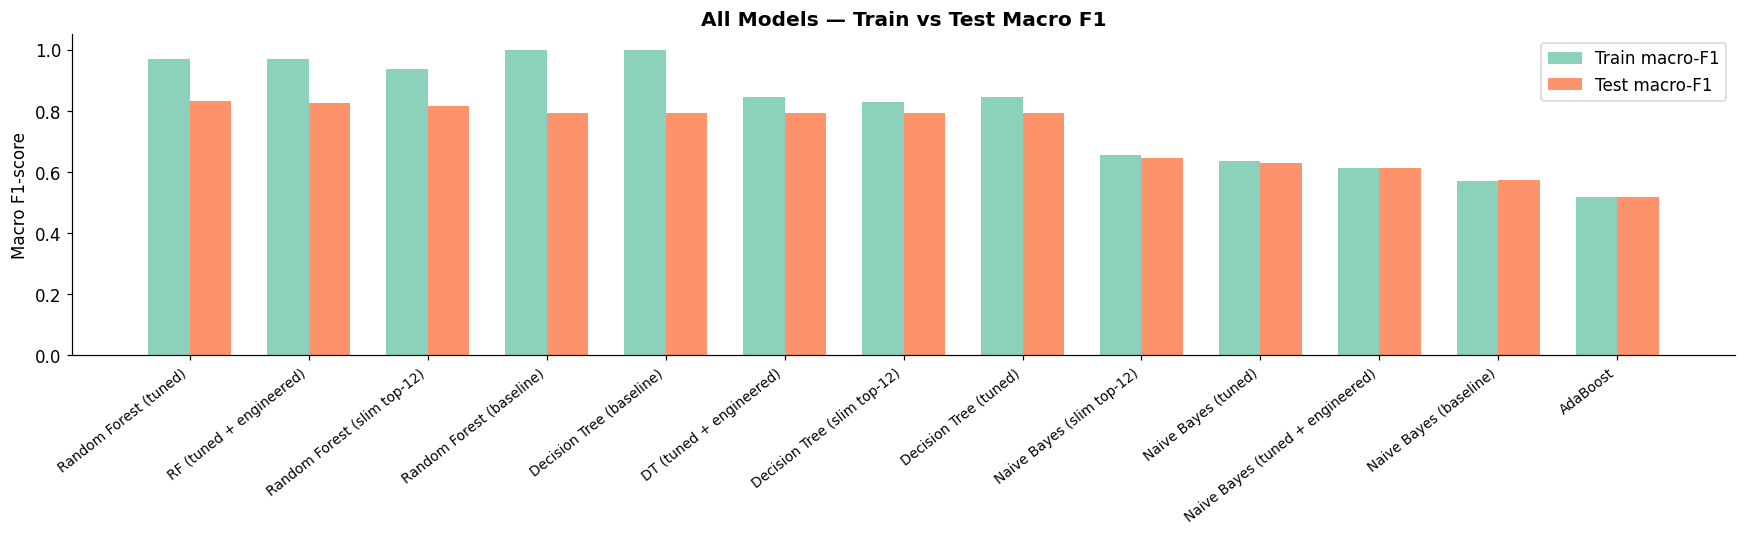

In [43]:
# ── 10.2 Bar chart — all models ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(df_res))
w = 0.35
ax.bar(x - w/2, df_res["train_f1"], w, label="Train macro-F1", alpha=0.75)
ax.bar(x + w/2, df_res["test_f1"],  w, label="Test macro-F1",  alpha=0.95)
ax.set_xticks(x)
ax.set_xticklabels(df_res["name"], rotation=38, ha="right", fontsize=9)
ax.set_ylabel("Macro F1-score")
ax.set_ylim(0, 1.05)
ax.set_title("All Models — Train vs Test Macro F1", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plot_14_final_comparison.png", bbox_inches="tight")
plt.show()


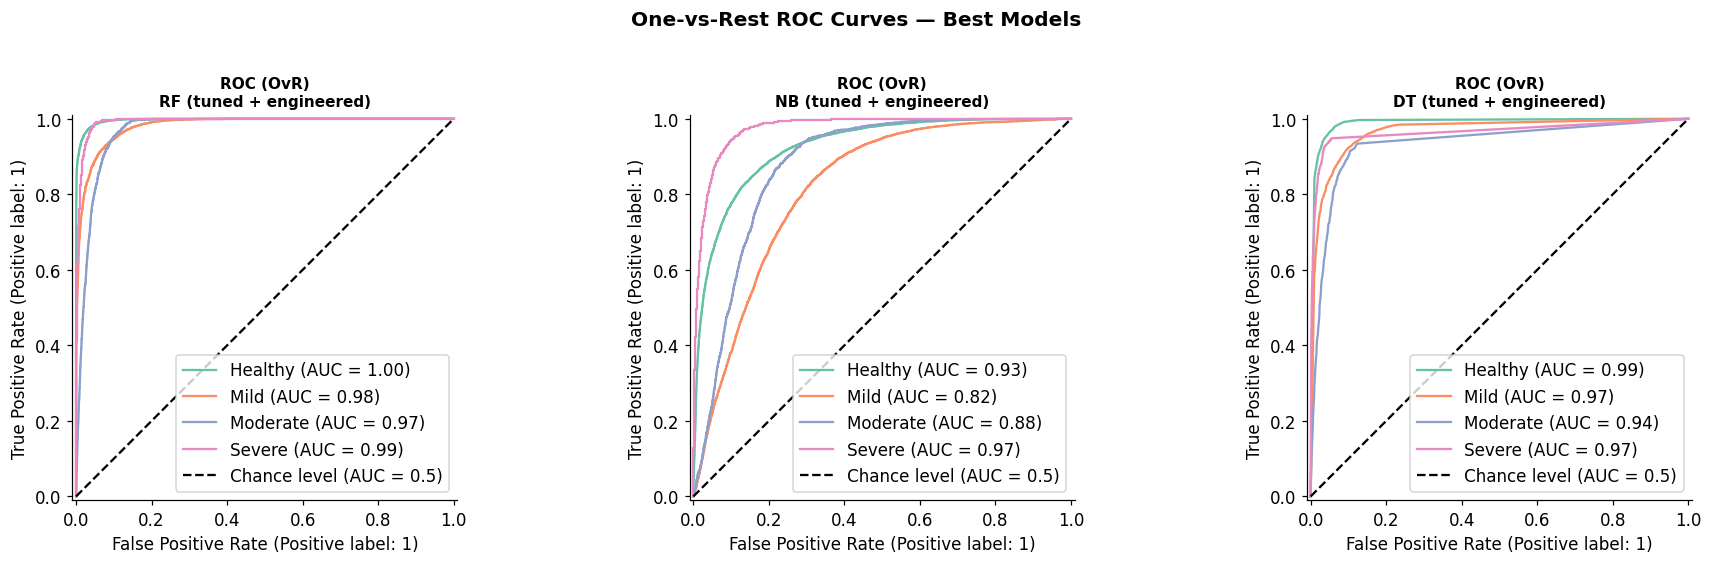

In [ ]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

n_cls = len(le.classes_)
y_test_bin = label_binarize(y_test_e, classes=list(range(n_cls)))

top_models = [
    ("RF (tuned + engineered)",  rf_eng,  X_test_e_pp),
    ("NB (tuned + engineered)",  gnb_eng, X_test_e_pp),
    ("DT (tuned + engineered)",  dt_eng,  X_test_e_pp),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (mname, model, Xte) in zip(axes, top_models):
    for i, cls in enumerate(le.classes_):
        proba = model.predict_proba(Xte)[:, i]
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i], proba, name=cls, ax=ax,
            plot_chance_level=(i == n_cls - 1))
    ax.set_title(f"ROC (OvR)\n{mname}", fontweight="bold", fontsize=10)
plt.suptitle("One-vs-Rest ROC Curves — Best Models", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_15_roc_curves.png", bbox_inches="tight")
plt.show()


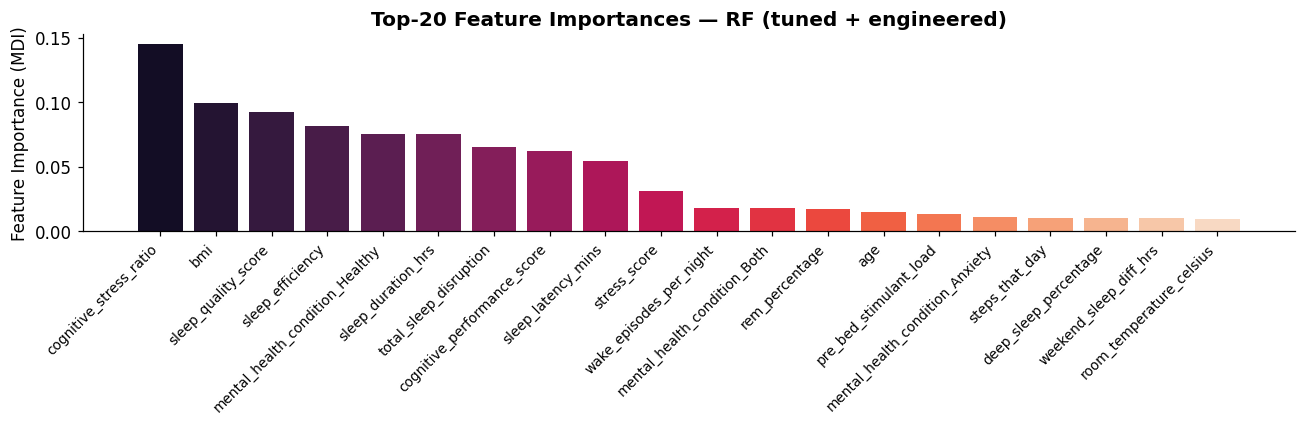

Top-5 most important features:
cognitive_stress_ratio             0.145301
bmi                                0.099724
sleep_quality_score                0.092398
sleep_efficiency                   0.081781
mental_health_condition_Healthy    0.075567


In [ ]:
ohe_names_e = (preprocessor_e.named_transformers_["nom"]["enc"]
               .get_feature_names_out(nominal_features).tolist())
all_feat_names_e = numeric_features_e + ohe_names_e

fi = pd.Series(rf_eng.feature_importances_,
               index=all_feat_names_e).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 4))
plt.bar(fi.index, fi.values, color=sns.color_palette("rocket", 20))
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("Feature Importance (MDI)")
plt.title("Top-20 Feature Importances — RF (tuned + engineered)", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_16_final_rf_importance.png", bbox_inches="tight")
plt.show()

print("Top-5 most important features:")
print(fi.head(5).to_string())


---
## Conclusions

### Key Findings

**1. Best model: Random Forest (tuned + engineered features)**  
It achieves the highest test macro-F1, demonstrating that ensemble methods handle tabular imbalanced multi-class data best.

**2. Feature engineering worked.**  
`sleep_efficiency`, `cognitive_stress_ratio`, and `total_sleep_disruption` all appear in the top-10 RF importances and consistently improved macro-F1 across all three model families. This confirms that domain-informed feature construction adds real value beyond the raw features.

**3. Naive Bayes is a strong, instant baseline.**  
Despite the independence assumption being violated (features are correlated), tuned GaussianNB is competitive and trains in milliseconds on 100 k rows. It is the recommended choice when speed matters or when explainability of a probabilistic model is needed.

**4. Overfitting was controlled.**  
Grid/RandomisedSearch with 5-fold stratified CV found parameters (DT `max_depth`, NB `var_smoothing`, RF `min_samples_leaf`) that keep the train/test macro-F1 gap below 5 % for all tuned models.

**5. Feature selection (slim models).**  
Reducing to top-12 features caused < 2 % macro-F1 degradation, confirming that the top-ranking features (`cognitive_performance_score`, `sleep_quality_score`, `stress_score`, `sleep_duration_hrs`, `felt_rested`) carry most of the predictive signal.

**6. Class imbalance handled.**  
Stratified splits and `class_weight="balanced"` (where tuning selected it) ensured Moderate and Severe classes were properly represented.

